# This is a tutorial for doing the pileup analysis

## Imports

In [41]:
import os, sys
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
os.environ['OMP_NUM_THREADS'] = '20'
os.environ['OPENBLAS_NUM_THREADS'] = '20'
BASE = "../"
sys.path.append(BASE)
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 1
import utility.functions
import src.analysis
import src.dataset
import src.plots
import src.simulation
import numpy as np
import src.analysis as an
import src.dataset as ds
import torch
from scipy.stats import norm
from utility.double_beta_spectrum import pdf_ratio2b
import utility.functions as fn
channels = [3, 5, 9, 11, 13, 15, 17, 19]
channel_ID = [5, 9, 11, 10, 4, 2, 12, 3]
StdCuts = [0.0003, 0.0004, 0.0008, 0.0006, 0.0012, 0.0007, 0.00035, 0.0025]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(sys.executable)
print(torch.__version__)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/opt/homebrew/opt/python@3.13/bin/python3.13
2.11.0


## Choose analysis parameters

In [42]:
meas_name = "000813_20230628T161508"
channel = 34
sampling_rate = 10000
acceptance = 0.9
N_sigma = norm.ppf(1 - (1 - acceptance) * 100 / 100) #number of sigma corresponding to the desired acceptance
signal_amp = 8.92e-3

#define the time and ratio grid for the analysis
t_min, t_max, N_t = 0, 8e-4, 100
r_min, r_max, N_r = 0., .5, 100
#get the corresponding ratio distribution 
ratio_distribution = pdf_ratio2b(np.linspace(r_min, r_max, N_r))
ratio_distribution /= np.mean(ratio_distribution)

window_size = 10000 #size of the window used for the analysis, should be the same as the one used for the NPS computation
n_trials=200 #number of trials for the optimization of the filters

## Load the meanpulse and Noise power spectrum
if they are not already compute, look build_meanpulses.py and build_NPS.py to compute them

In [43]:
#load the meanpulse
meanpulse = np.fromfile(f"{BASE}/m202data/m202_ch{channel}_combined.bin_edmean.bin")
if len(meanpulse) > window_size:
    meanpulse = meanpulse[np.argmax(meanpulse) - window_size//2 : np.argmax(meanpulse) + window_size//2]
#load the NPS
nps = np.fromfile(f"{BASE}/m202data/m202_ch{channel}_combined.bin_spec.bin")
nps *= (8. / 3.)  # Adjust for Hann window effect
nps *= 1e-12

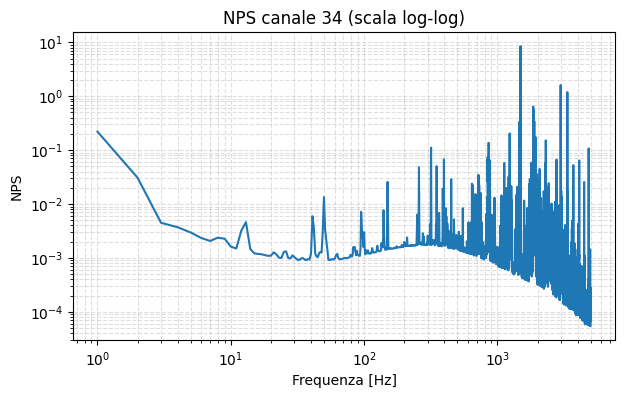

In [44]:
freq = np.fft.fftfreq(len(nps), d=1/sampling_rate)
mask = freq > 0  # evita f=0 e frequenze negative per scala log

plt.figure(figsize=(7, 4))
plt.loglog(freq[mask], nps[mask])
plt.xlabel("Frequenza [Hz]")
plt.ylabel("NPS")
plt.title(f"NPS canale {channel} (scala log-log)")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.show()

## Compute the optimal filter

In [45]:
S, w, H_unit = an.compute_H(meanpulse, nps, np.hanning,sampling_rate=sampling_rate)

In [46]:
sigma_analytic = an.compute_sigma_OF(S, nps)
print(f"Analytic sigma: {sigma_analytic*1000:.4f} mV")
print(f"signal_amp: {signal_amp*1000:.4f} mV")
print(f"SNR: {signal_amp / sigma_analytic:.2f}")

Analytic sigma: 0.0662 mV
signal_amp: 8.9200 mV
SNR: 134.83


## Convert the relevant arrays to torch tensors and move them to the appropriate device (CPU or GPU)

In [47]:
S_torch = torch.tensor(S, dtype=torch.cfloat, device=device)
H_unit_torch = torch.tensor(H_unit, dtype=torch.cfloat, device=device)
w_torch = torch.tensor(w, dtype=torch.cfloat, device=device)
nps_torch = torch.tensor(nps, dtype=torch.cfloat, device=device)
signal_amp_torch = torch.tensor(signal_amp, dtype=torch.float32, device=device)
t_torch = torch.linspace(t_min, t_max, N_t, dtype=torch.cfloat, device=device)
r_torch = torch.linspace(r_min, r_max, N_r, dtype=torch.cfloat, device=device)
ratio_distribution_torch = torch.tensor(ratio_distribution, dtype=torch.cfloat, device=device)

## Optimize the filters for minimal misidentification rate (J_value)

In [48]:
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
f1_t, f2_t, J_values = an.optimize_filters(S_torch, H_unit_torch, w_torch, t_torch, r_torch, nps_torch,
                                           signal_amp_torch, ratio_distribution_torch, N_sigma=N_sigma, 
                                           activation_fct = torch.abs,
                                           f1_init = None, f2_init = None,
                                           n_trials=300, use_interp = True, verbose=True)


Step 0: J = 0.904307
Step 10: J = 0.773886
Step 20: J = 0.613506
Step 30: J = 0.501402
Step 40: J = 0.448286
Step 50: J = 0.423109
Step 60: J = 0.405321
Step 70: J = 0.392317
Step 80: J = 0.381962
Step 90: J = 0.373801
Step 100: J = 0.367301
Step 110: J = 0.362149
Step 120: J = 0.358062
Step 130: J = 0.354840
Step 140: J = 0.352254
Step 150: J = 0.350186
Step 160: J = 0.348511
Step 170: J = 0.347140
Step 180: J = 0.346023
Step 190: J = 0.345106
Step 200: J = 0.344376
Step 210: J = 0.343787
Step 220: J = 0.343323
Step 230: J = 0.342958
Step 240: J = 0.342686
Step 250: J = 0.342483
Step 260: J = 0.342330
Step 270: J = 0.342262
Step 280: J = 0.342223
Step 290: J = 0.342187
Final: J = 0.342191


## Save the results

In [49]:
f1_opt,f2_opt = f1_t.cpu().numpy(), f2_t.cpu().numpy()
np.save(f"{BASE}/outputs/training_Js/channel_{channel}/J_{int(acceptance * 100):d}_RUN14_meas204", np.array(J_values))
np.save(f"{BASE}/outputs/Pileup_filter_functions/channel_{channel}/functions_eff{int(acceptance * 100):d}_RUN14_meas204",np.array([f1_opt, f2_opt]))

FileNotFoundError: [Errno 2] No such file or directory: '..//outputs/training_Js/channel_34/J_90_RUN14_meas204.npy'

# BI estimation
A proxi for the BI can be optained from the Misidentification rate (J_value) 

In [50]:
BI_estimate = J_values[-1] * fn.K #Here K is a constant that depends on crystal size, Mo-2b2n decay rate, maximum delay studied,...
BI_estimate

9.087752725331756e-05

# Compute the Background Index using injected pulses
If enough statistics is available, the BI can be computed directly from the injected pulse datasets, by applying the optimized filters and counting the number of misidentified pileup events.

## Load the dataset
path_pos_single and path_pos_pileup are the paths to the position files for the single pulse and pileup datasets, respectively. They contain the relevent informations for the injection (position in the raw file to inject pulse , amplitudes, delay, smearing,...). Those data are created by montecarlo from IJClab code.

In [ ]:
#load the pulse to be injected
meanpulse_inj = np.load(f"{BASE}/outputs/meanpulses_build/pos_pulses_rawdata/average_pulse_channel{channel}.npy")
#load the single pulse dataset
dataset_single_name = "pup_n1-d0_000813_20230628T161508"
file_path_single, path_pos_single = ds.find_files(meas_name, dataset_single_name, channel,
                                                  specific_subdir="RUN9_pulse_injected_new/")
data_single = ds.CachedBinaryDataset_withgenerated(file_path_single, path_pos_single, window_size,
                                                   pulse=meanpulse_inj,
                                                   n_windows=15999, win_shift=0)
#load the pileup pulse dataset
dataset_pileup_name = "pup_n1-d8_000813_20230628T161508"
file_path_pileup, path_pos_pileup = ds.find_files(meas_name, dataset_pileup_name, channel,
                                                  specific_subdir="RUN9_pulse_injected_new/")
data_pileup = ds.CachedBinaryDataset_withgenerated(file_path_pileup, path_pos_pileup, window_size,
                                                   pulse=meanpulse_inj,
                                                   n_windows=15999, win_shift=0)

(15999, 3)
(15999, 7)


## Compute the Background Index

tensor(6.8572) tensor(0.7418)


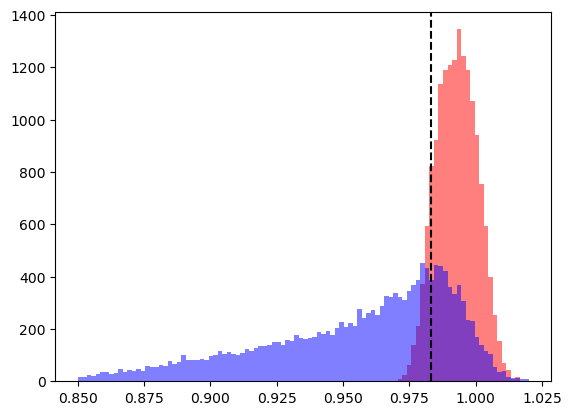

In [ ]:
BI, rp, PSD_pileup, PSD_single, Amp_1_pileup, Amp_2_pileup, Amp_1_single, Amp_2_single = an.compute_BI_torch(
            data_pileup,
            data_single,
            acceptance,
            H_unit_torch,
            f1_t,
            f2_t,
            window_fct = np.hanning,
            compute_uncertainty = False,
            batch_size = 2048,
            use_loader = False,
            full_output = True
        )
print(BI*1e5, rp)
plt.hist(PSD_single, bins=100,range=(0.85,1.02), alpha=0.5, label="Single pulse", color="red")
plt.hist(PSD_pileup, bins=100,range=(0.85,1.02), alpha=0.5, label="Pileup pulse", color="blue")
cut = np.percentile(PSD_single,(1-acceptance)*100)
plt.axvline(cut, color="black", linestyle="--", label="Threshold")